In [10]:
import numpy as np
import torch
from train_reinforce import BinPacking_Environment, get_action_from_idx
from PackingUtils import *
from ModelEMS import *
import datetime
import random
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [11]:
def run_policy(item_list, model_filename, device_name, container_dim=(100, 100, 100), clip_num=50):
	device = torch.device(device_name)
	model = BPP_Model_EMS(num_placement=clip_num, batch_size=1, embed_size=128, feature_mlp_layers=[256, 128], feature_mlp_output=64).to(device)
	model.load_state_dict(torch.load(model_filename, map_location=device, weights_only=True))
	max_steps = 200
	used_bins_idx = []

	env = BinPacking_Environment(container_dim, item_list, clip_num=clip_num, device=device_name)
	step_cnt = 0
	done = False
	states, action_ids, rewards, actions = [], [], [], []
	model.eval()
	while not done:
		placement, item_info, height_map, feasibility_mask = env.get_state()
		ems_state, item_state, ems_feature, item_feature, logits_raw_, logits = model(
			placement,
			item_info,
			height_map,
			feasibility_mask
		)
		# print(feasibility_mask)
		# print(logits)
		# if torch.any(logits < 0) or torch.any(logits == torch.nan) or torch.any(logits == torch.inf):
		# 	print(f"logits < 0 exists")
		# 	print(logits)
		# print(logits)
		try:
			# action_idx = torch.multinomial(logits, 1).item()
			# action_idx = torch.topk(logits, 1, dim=-1).indices[0].item()
			action_idx = torch.argmax(logits, dim=-1).item()
			# print(logits)
		except Exception as e:
			print(f"Error: {e}")
			print(item_list)
			print(logits)
			print(logits_raw_)
			print("feasibility mask: ", feasibility_mask)
			print("placement: ", placement)
			print("item_info: ", item_info)
			print("EMS state: ", ems_state)
			print("Item state: ", item_state)
			print("height_map: ", height_map)

			print("EMS feature: ", ems_feature)
			print("Item feature: ", item_feature)
			print("step count: ", step_cnt)
			break
		# print(action_idx)
		item_size = item_info.cpu().detach().numpy()[0, 0].astype(int).tolist()
		# print(item_size, item_size[0])
		action = get_action_from_idx(placement, action_idx, clip_num, height_map=env.height_map, item_size=item_size, return_height=True)
		ax, ay, ar, height = action
		print(f"action: {action}")
		reward, done = env.step((ax, ay, ar), False)
		if reward == 0:
			print(f"skip this step: item {item_info.cpu().detach().numpy().tolist()}")
			env.item_ptr += 1
			if env.item_ptr >= len(item_list):
				done = True
		else:
			states.append((placement, item_state, height_map, feasibility_mask))
			rewards.append(reward)
			action_ids.append(action_idx)
			actions.append(action)
			if env.item_ptr not in used_bins_idx:
				used_bins_idx.append(env.item_ptr)
		if step_cnt >= max_steps and not done:
			done = True
			# rewards[-1] -= env.get_remaining_cnt() * 0.1
			break
		step_cnt += 1
	print(f"Used items: {env.used} / {len(env.items_list)}")
	return env, used_bins_idx, actions

In [12]:
# container_dim = (52, 40, 17)
# container_dim = (100, 100, 100)
container_dim = (37, 26, 13)
items = np.load(f"dataset_map/item_list_{container_dim}.npy")
# print(items)
item_list_ = items.tolist()
print(item_list_)
item_list = []
for item in item_list_:
	item_list.append(np.array(item))
# train()
# random.shuffle(item_list)
# item_list = item_list[:15]
item_list.sort(key=lambda x: max(x[0], x[1]), reverse=True)
print(item_list)
# random.shuffle(item_list)


[[1, 9, 4], [4, 7, 4], [4, 2, 4], [2, 18, 10], [5, 5, 9], [5, 3, 3], [5, 2, 4], [5, 4, 1], [2, 3, 3], [3, 3, 3], [10, 9, 13], [10, 1, 8], [3, 4, 8], [10, 1, 3], [10, 1, 2], [2, 1, 3], [2, 1, 3], [2, 16, 3], [4, 1, 4], [5, 11, 13], [5, 3, 13], [7, 16, 13], [3, 16, 13], [15, 3, 8], [15, 3, 5], [1, 1, 1], [1, 1, 3], [2, 4, 4], [2, 4, 4], [10, 23, 13], [2, 23, 13], [5, 21, 4], [5, 5, 4], [5, 26, 5], [5, 26, 4], [5, 3, 1], [5, 3, 2], [3, 12, 13], [3, 11, 13], [2, 3, 13], [2, 5, 13]]
[array([ 5, 26,  5]), array([ 5, 26,  4]), array([10, 23, 13]), array([ 2, 23, 13]), array([ 5, 21,  4]), array([ 2, 18, 10]), array([ 2, 16,  3]), array([ 7, 16, 13]), array([ 3, 16, 13]), array([15,  3,  8]), array([15,  3,  5]), array([ 3, 12, 13]), array([ 5, 11, 13]), array([ 3, 11, 13]), array([10,  9, 13]), array([10,  1,  8]), array([10,  1,  3]), array([10,  1,  2]), array([1, 9, 4]), array([4, 7, 4]), array([5, 5, 9]), array([5, 3, 3]), array([5, 2, 4]), array([5, 4, 1]), array([ 5,  3, 13]), array([5,

In [13]:
env, used_bins_idx, actions = run_policy(item_list, "models/model_20250112_124243_.pth", "cpu", container_dim=container_dim)
print(used_bins_idx)
print(actions)

action: (4, 0, 0, 0.0)
action: (4, 0, 0, 5.0)
action: (22, 0, 0, 0.0)
action: (36, 0, 0, 0.0)
action: (4, 0, 0, 9.0)
action: (6, 0, 0, 0.0)
action: (6, 10, 0, 10.0)
action: (29, 0, 0, 0.0)
action: (9, 0, 0, 0.0)
action: (36, 23, 0, 0.0)
action: (36, 23, 0, 8.0)
action: (12, 0, 0, 0.0)
action: (34, 0, 0, 0.0)
action: (12, 12, 0, 0.0)
action: (0, 0, 0, -1)
skip this step: item [[[10.0, 9.0, 13.0], [9.0, 10.0, 13.0]]]
action: (19, 23, 0, 0.0)
action: (19, 23, 0, 8.0)
action: (5, 0, 0, -1)
skip this step: item [[[10.0, 1.0, 2.0], [1.0, 10.0, 2.0]]]
action: (7, 16, 0, 0.0)
action: (0, 0, 0, -1)
skip this step: item [[[4.0, 7.0, 4.0], [7.0, 4.0, 4.0]]]
action: (0, 0, 0, -1)
skip this step: item [[[5.0, 5.0, 9.0], [5.0, 5.0, 9.0]]]
action: (4, 23, 0, 9.0)
action: (4, 21, 0, 9.0)
action: (0, 0, 0, -1)
skip this step: item [[[5.0, 4.0, 1.0], [4.0, 5.0, 1.0]]]
action: (0, 0, 0, -1)
skip this step: item [[[5.0, 3.0, 13.0], [3.0, 5.0, 13.0]]]
action: (0, 0, 0, -1)
skip this step: item [[[5.0, 5.0,

In [14]:
height_map = env.height_map
state = None
if env.item_ptr == len(item_list):
	print("success")
else:
	coming_item = env.items_list[env.item_ptr]
	print(f"coming item: {coming_item}")
	states = env.get_state()
utilization = env.get_utilization()
print(f"utilization: {utilization}")

success
utilization: 0.8356788741404126


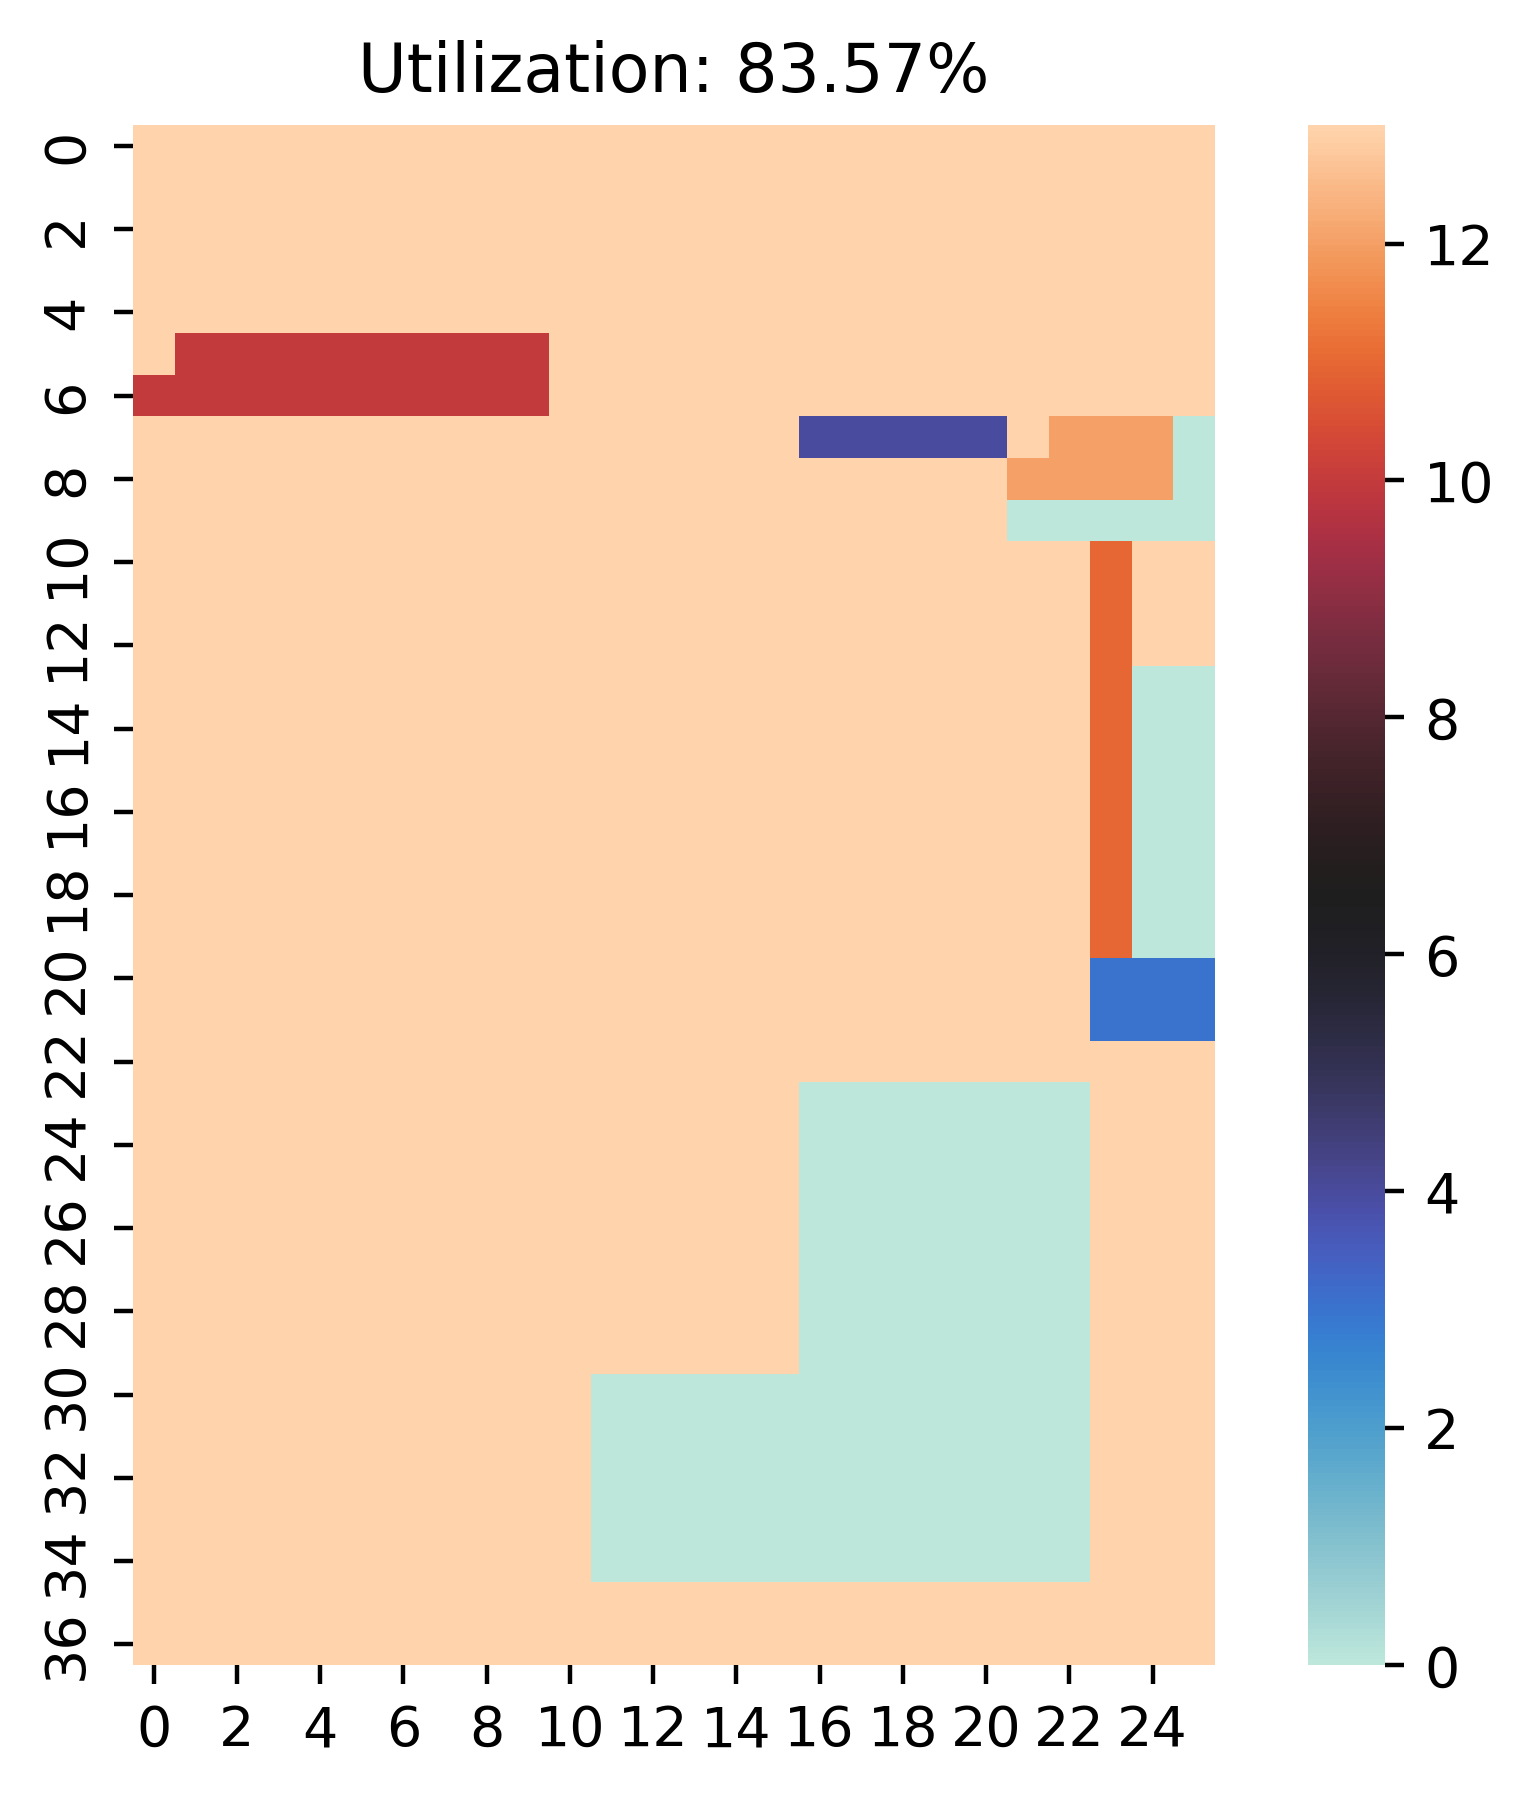

In [15]:
fig = plt.figure(figsize=(6, 5), dpi=400)
sns.heatmap(height_map, square=True, center=container_dim[2]/2)
plt.title("Utilization: {:.2f}%".format(utilization*100))
plt.savefig("test_bin_packing.png")

In [16]:
if state:
	print(f"placement: {states[0]}")

In [17]:
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
# fig = plt.figure(figsize=(6, 5), dpi=100)

def draw_bins_3d(container_dim, positions, sizes, filename):
    """
    Draws a 3D figure of bins given their positions and sizes.

    Parameters:
    - positions: List of tuples (x, y, z) representing the bottom-left-front corner of each bin.
    - sizes: List of tuples (dx, dy, dz) representing the dimensions of each bin.
    """
    fig = plt.figure(figsize=(6, 5), dpi=400)
    ax = fig.add_subplot(111, projection='3d')
    nums = len(positions)
    ranges = [random.random() for _ in range(nums)]
    print(ranges)
    color_list = plt.cm.tab20b(ranges)

    for i, (pos, size) in enumerate(zip(positions, sizes)):
        x, y, z = pos
        dx, dy, dz = size
        facecolor = color_list[i]

        # Define the vertices of the cuboid
        vertices = [
            [x+1, y, z],
            [x-dx+1, y, z],
            [x-dx+1, y+dy, z],
            [x+1, y+dy, z],
            [x+1, y, z+dz],
            [x-dx+1, y, z+dz],
            [x-dx+1, y+dy, z+dz],
            [x+1, y+dy, z+dz],
        ]
        print(vertices)

        # Define the 12 edges of the cuboid
        edges = [
            [vertices[0], vertices[1], vertices[2], vertices[3]],  # Bottom face
            [vertices[4], vertices[5], vertices[6], vertices[7]],  # Top face
            [vertices[0], vertices[1], vertices[5], vertices[4]],  # Front face
            [vertices[2], vertices[3], vertices[7], vertices[6]],  # Back face
            [vertices[1], vertices[2], vertices[6], vertices[5]],  # Right face
            [vertices[0], vertices[3], vertices[7], vertices[4]],  # Left face
        ]

        # Add the cuboid to the plot
        ax.add_collection3d(Poly3DCollection(edges, alpha=1.0, edgecolor='k', facecolor=facecolor, linewidth=0.1))

    # Set axes limits and labels
    max_dim = max(max(pos[i] + size[i] for pos, size in zip(positions, sizes)) for i in range(3))
    ax.set_xlim(0, container_dim[0])
    ax.set_ylim(0, container_dim[1])
    ax.set_zlim(0, container_dim[2])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(10, 30)

    # plt.show()
    plt.savefig(filename)

# Example usage
# positions = [(0, 0, 0), (1, 1, 1), (2, 2, 2)]  # Bottom-left-front positions of bins
# sizes = [(1, 1, 1), (1, 2, 1), (2, 1, 2)]  # Dimensions (dx, dy, dz) of each bin

# draw_bins_3d(positions, sizes)

[[5, 26, 5], [5, 26, 4], [10, 23, 13], [2, 23, 13], [5, 21, 4], [2, 18, 10], [2, 16, 3], [7, 16, 13], [3, 16, 13], [15, 3, 8], [15, 3, 5], [3, 12, 13], [5, 11, 13], [3, 11, 13], [10, 1, 8], [10, 1, 3], [1, 9, 4], [5, 3, 3], [5, 2, 4], [5, 3, 1], [2, 5, 13], [2, 4, 4], [2, 4, 4], [2, 3, 3], [2, 3, 13], [1, 1, 1], [1, 1, 3]]
[[4, 0, 0.0], [4, 0, 5.0], [22, 0, 0.0], [36, 0, 0.0], [4, 0, 9.0], [6, 0, 0.0], [6, 10, 10.0], [29, 0, 0.0], [9, 0, 0.0], [36, 23, 0.0], [36, 23, 8.0], [12, 0, 0.0], [34, 0, 0.0], [12, 12, 0.0], [19, 23, 0.0], [19, 23, 8.0], [7, 16, 0.0], [4, 23, 9.0], [4, 21, 9.0], [4, 23, 12.0], [9, 16, 0.0], [8, 21, 4.0], [8, 21, 8.0], [21, 23, 0.0], [12, 24, 0.0], [7, 21, 12.0], [5, 0, 10.0]]
[0.15563555606771629, 0.611931548085174, 0.4212164323224685, 0.052585324201377404, 0.726763781031167, 0.6596762465085174, 0.4045359174328924, 0.36454048075669243, 0.336984139504222, 0.6531837296927513, 0.30996856306321585, 0.2640080360302234, 0.21667657121548067, 0.07435390412213128, 0.4072

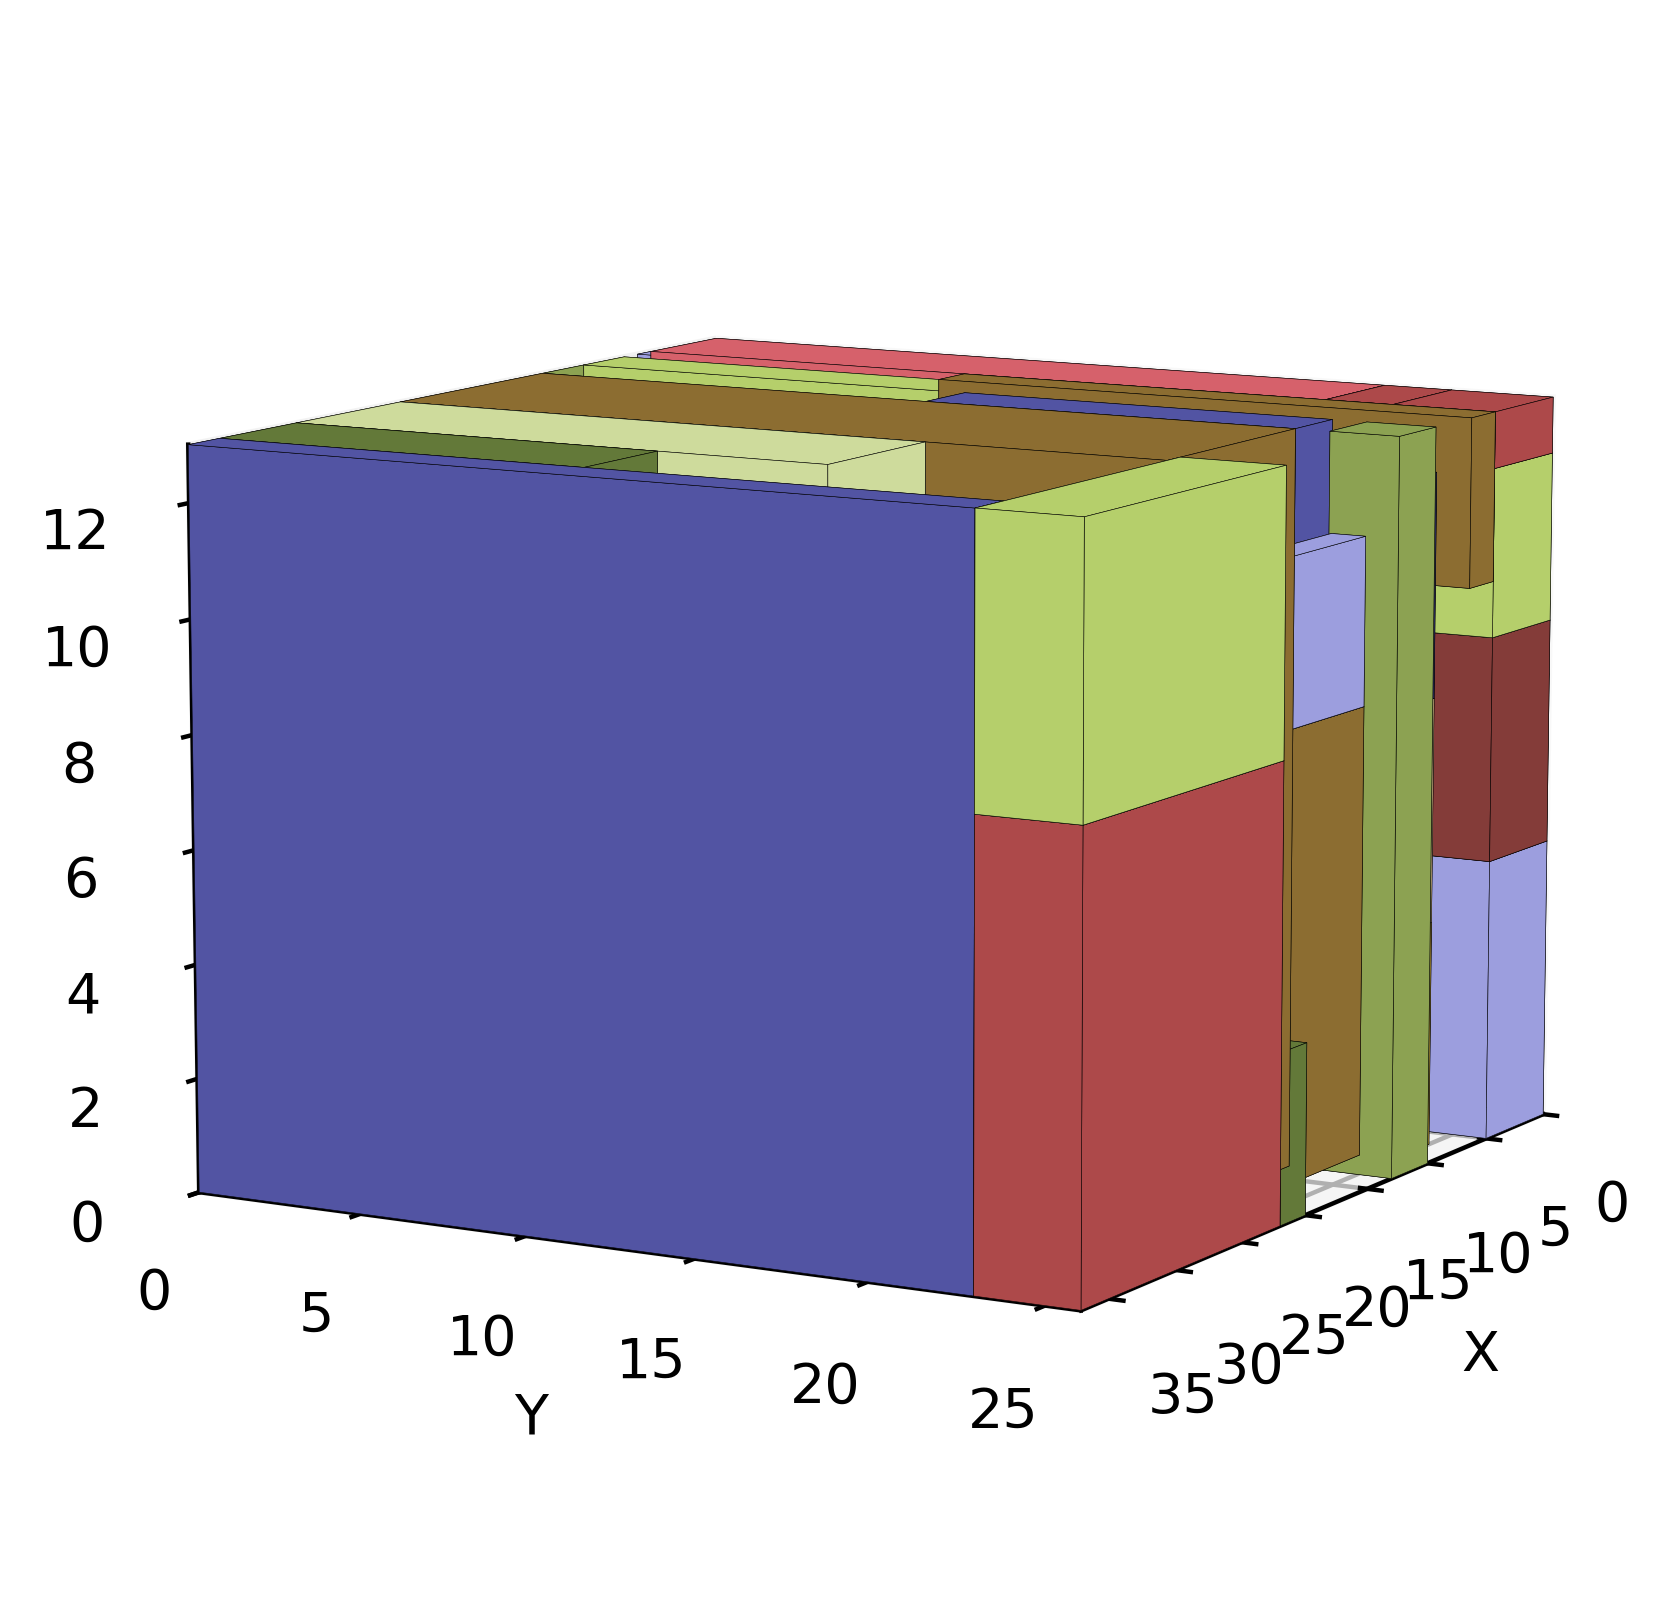

In [18]:

# ax = fig.add_subplot(111, projection='3d')

bins = [item_list[idx-1].tolist() for idx in used_bins_idx]
positions = []
print(bins)
n_used_bins = len(used_bins_idx)
for i in range(n_used_bins):
	xpos, ypos, rotate, zpos = actions[i]
	if rotate == 1:
		bins[i] = [bins[i][1], bins[i][0], bins[i][2]]
	positions.append([xpos, ypos, zpos])
print(positions)
# ax.voxels(bins, edgecolor='k')
draw_bins_3d(container_dim, positions, bins, f"models/bin_packing_3d_{container_dim}.png")